In [2]:
print("Employee Retention Prediction Project")

Employee Retention Prediction Project


# Import Libraries

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Libraries imported successfully..!")

Libraries imported successfully..!


# Load Dataset

In [4]:
train_df=pd.read_csv("aug_train.csv")
test_df=pd.read_csv("aug_test.csv")

In [5]:
print(train_df['city'].unique())

['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79' 'city_76'
 'city_77' 'city_81' 'city_131' 'city_44' 'city_117'

In [6]:
print(sorted(train_df['city'].unique())[:20])

['city_1', 'city_10', 'city_100', 'city_101', 'city_102', 'city_103', 'city_104', 'city_105', 'city_106', 'city_107', 'city_109', 'city_11', 'city_111', 'city_114', 'city_115', 'city_116', 'city_117', 'city_118', 'city_12', 'city_120']


# Dataset Overview

In [7]:
train_df.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [8]:
test_df.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [10]:
train_df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

Shape of dataset train,test

In [11]:
print(train_df.shape)
print(test_df.shape)

(19158, 14)
(2129, 13)


# Missing value analysis

In [12]:
train_df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

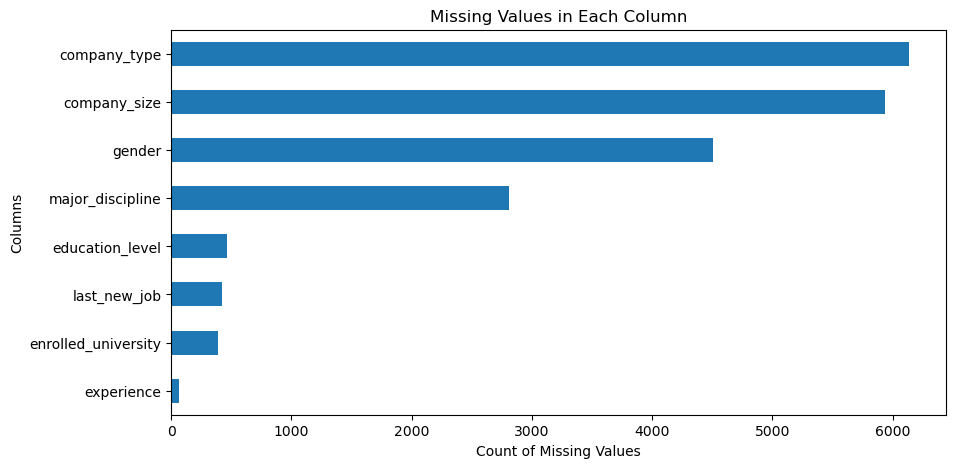

In [13]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')

plt.title("Missing Values in Each Column")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.show()

# EDA Visualization


## Target Distribution



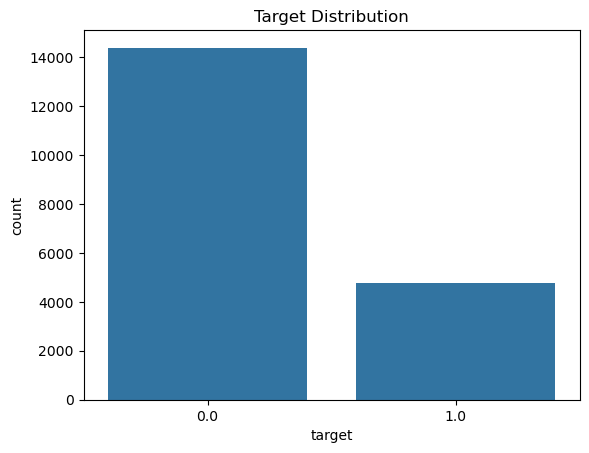

In [14]:
sns.countplot(x='target', data=train_df)
plt.title("Target Distribution")
plt.show()

for visualization

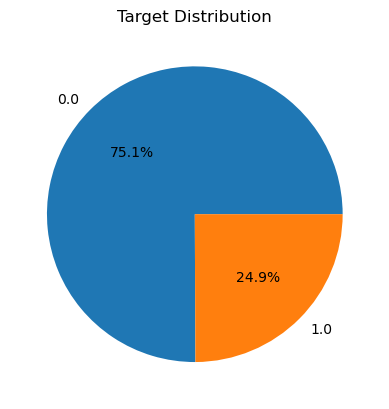

In [15]:
train_df['target'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Target Distribution")
plt.ylabel("")
plt.show()

## Gender VS Target


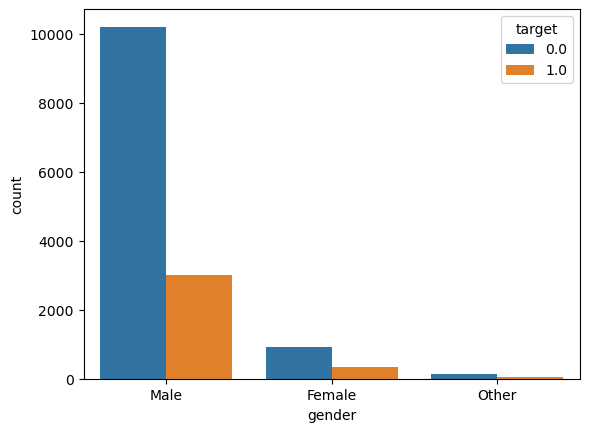

In [16]:
sns.countplot(x='gender', hue='target', data=train_df)
plt.show()

## Educational level VS Target

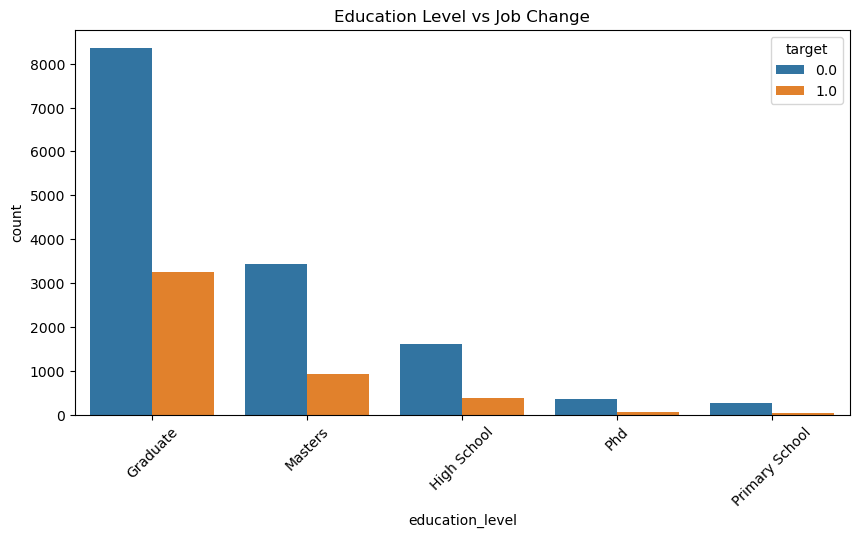

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='education_level',
    hue='target',
    data=train_df
)

plt.xticks(rotation=45)
plt.title("Education Level vs Job Change")
plt.show()

## Experience VS Target

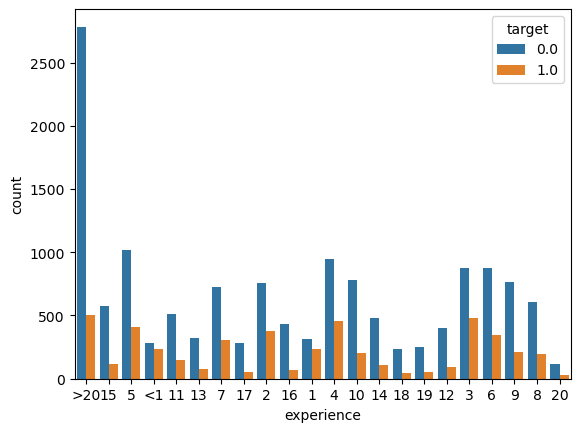

In [18]:
sns.countplot(x='experience', hue='target', data=train_df)
plt.show()

# Data Preprocessing

## Filling Missing Values

In [19]:
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    else:
        train_df[col] = train_df[col].fillna(train_df[col].median())

label encoding

In [20]:
encoders = {}

for col in train_df.columns:
    if train_df[col].dtype == 'object':

        train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

        le = LabelEncoder()

        train_df[col] = le.fit_transform(train_df[col])

        encoders[col] = le

In [21]:
print(encoders.keys())

dict_keys(['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job'])


In [22]:
for col in encoders.keys():

    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

    test_df[col] = test_df[col].map(
        lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0]
    )

    test_df[col] = encoders[col].transform(test_df[col])

In [23]:
train_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,5,0.920,1,0,2,0,5,21,4,5,0,36,1.0
1,29725,77,0.776,1,1,2,0,5,6,4,5,4,47,0.0
2,11561,64,0.624,1,1,0,0,5,15,4,5,5,83,0.0
3,33241,14,0.789,1,1,2,0,1,20,4,5,5,52,1.0
4,666,50,0.767,1,0,2,2,5,21,4,1,3,8,0.0


# Feature Selection

In [24]:
X = train_df.drop(['target','enrollee_id'], axis=1)
y = train_df['target']

# Train & Test Splitting

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15326, 12)
(3832, 12)
(15326,)
(3832,)


# Logistic Regression

In [27]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7656576200417536


# Random Forest Classifier

In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))
      

Random Forest Accuracy: 0.7659185803757829


# XGBoost

In [29]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.7680062630480167


# lightgbm

In [30]:
lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, lgbm_pred))

[LightGBM] [Info] Number of positive: 3825, number of negative: 11501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 515
[LightGBM] [Info] Number of data points in the train set: 15326, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.249576 -> initscore=-1.100876
[LightGBM] [Info] Start training from score -1.100876
LightGBM Accuracy: 0.7753131524008351


In [31]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3825, number of negative: 11501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 515
[LightGBM] [Info] Number of data points in the train set: 15326, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.249576 -> initscore=-1.100876
[LightGBM] [Info] Start training from score -1.100876


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Accuracy Comparison

In [32]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Random Forest',
             'XGBoost',
             'LightGBM'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.765658
1,Random Forest,0.765919
2,XGBoost,0.768006
3,LightGBM,0.775313


# Confusion Matrix

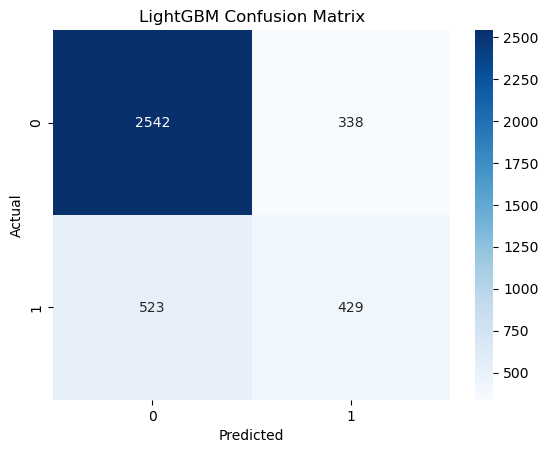

In [33]:
cm = confusion_matrix(y_test, lgbm_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [34]:
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      2880
         1.0       0.56      0.45      0.50       952

    accuracy                           0.78      3832
   macro avg       0.69      0.67      0.68      3832
weighted avg       0.76      0.78      0.77      3832



# ROC-AUC Score

In [35]:
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

print("ROC-AUC Score:",
      roc_auc_score(y_test, lgbm_prob))

ROC-AUC Score: 0.7781572785364146


# best accuracy from above model

In [36]:
best_accuracy = results['Accuracy'].max()

print("Best Model Accuracy:", best_accuracy)

Best Model Accuracy: 0.7753131524008351


# Predict on aug_test.csv

In [37]:
test_features = test_df.drop('enrollee_id', axis=1)

In [38]:
final_predictions = lgbm.predict(test_features)

print("Predictions Generated Successfully")
print(final_predictions[:10])

Predictions Generated Successfully
[0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]


# Saving Prediction

In [39]:
submission = pd.DataFrame({
    'enrollee_id': test_df['enrollee_id'],
    'prediction': final_predictions
})

In [40]:
submission.to_csv("predictions.csv", index=False)

print("predictions.csv saved successfully")

predictions.csv saved successfully


In [41]:
pd.read_csv("predictions.csv").head()

,enrollee_id,prediction
0,32403,0.0
1,9858,0.0
2,31806,1.0
3,27385,0.0
4,27724,0.0


# Conclusion

In [42]:
print("Project Conclusion")
print("- Employee Job Change Prediction model developed successfully.")
print("- Data preprocessing and EDA were performed.")
print("- Multiple models were trained and evaluated.")
print("- LightBGM was selected as the final model.")
print("- Predictions were generated on aug_test.csv.")
print("- Results were exported to predictions.csv.")
print("- The model can help organizations identify employees likely to change jobs.")

Project Conclusion
- Employee Job Change Prediction model developed successfully.
- Data preprocessing and EDA were performed.
- Multiple models were trained and evaluated.
- LightBGM was selected as the final model.
- Predictions were generated on aug_test.csv.
- Results were exported to predictions.csv.
- The model can help organizations identify employees likely to change jobs.


In [43]:
import joblib

joblib.dump(lgbm, "employee_model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("Model and encoders saved successfully")


Model and encoders saved successfully
